In [1]:
import cv2
import os

# 🔴 CHANGE THIS PATH ONLY
base_path = "C:/Users/Dell/Documents/AIDSLAB_3rdsem/AIDSLAB_4thsem/Balanced Accident Video Dataset"

splits = ["train", "test", "val"]
classes = ["Minor", "Moderate", "Major"]

for split in splits:
    for cls in classes:

        video_folder = os.path.join(base_path, split, cls)
        frame_folder = os.path.join(base_path, "frames", split, cls)

        os.makedirs(frame_folder, exist_ok=True)

        for video_file in os.listdir(video_folder):

            video_path = os.path.join(video_folder, video_file)
            cap = cv2.VideoCapture(video_path)

            frame_count = 0
            saved_count = 0

            while True:
                ret, frame = cap.read()
                if not ret:
                    break

                # Save every 5th frame
                if frame_count % 15 == 0 and saved_count < 50:
                    frame = cv2.resize(frame, (224, 224))

                    frame_name = f"{video_file}_frame{saved_count}.jpg"
                    frame_path = os.path.join(frame_folder, frame_name)

                    cv2.imwrite(frame_path, frame)
                    saved_count += 1

                frame_count += 1

            cap.release()



KeyboardInterrupt: 

In [1]:
print("✅ Frame extraction completed!")

✅ Frame extraction completed!


In [ ]:
!pip install opencv-python

In [ ]:
!pip install tensorflow

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_path = "C:/Users/Dell/Documents/AIDSLAB_3rdsem/AIDSLAB_4thsem/Balanced Accident Video Dataset/frames"

train_dir = base_path + "/train"
val_dir = base_path + "/val"
test_dir = base_path + "/test"

datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical' 
)

Found 18275 images belonging to 3 classes.
Found 4085 images belonging to 3 classes.
Found 3893 images belonging to 3 classes.


In [2]:
# ==============================
# 1. Import Libraries
# ==============================
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

# ==============================
# 2. Set Dataset Path
# ==============================
base_path = "C:/Users/Dell/Documents/AIDSLAB_3rdsem/AIDSLAB_4thsem/Balanced Accident Video Dataset/frames"

train_dir = base_path + "/train"
val_dir = base_path + "/val"
test_dir = base_path + "/test"

# ==============================
# 3. Load Data
# ==============================
datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=16,   # reduced for smoother performance
    class_mode='categorical'
)

val_data = datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical'
)

test_data = datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=16,
    class_mode='categorical'
)

# ==============================
# 4. Build Model (MobileNetV2)
# ==============================
base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False  # freeze pretrained layers

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')   # 3 classes
])

# ==============================
# 5. Compile Model
# ==============================
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ==============================
# 6. Train Model
# ==============================
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

# ==============================
# 7. Evaluate Model
# ==============================
test_loss, test_acc = model.evaluate(test_data)

print("\nTest Accuracy:", test_acc)

# ==============================
# 8. Save Model (IMPORTANT)
# ==============================
model.save("car_crash_model.h5")

print("Model saved successfully!")

Found 18275 images belonging to 3 classes.
Found 4085 images belonging to 3 classes.
Found 3893 images belonging to 3 classes.
Epoch 1/5
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 1082s 940ms/step - accuracy: 0.7112 - loss: 0.6541 - val_accuracy: 0.5398 - val_loss: 1.2165
Epoch 2/5
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 1176s 1s/step - accuracy: 0.9152 - loss: 0.2304 - val_accuracy: 0.5354 - val_loss: 1.4967
Epoch 3/5
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 1624s 1s/step - accuracy: 0.9485 - loss: 0.1360 - val_accuracy: 0.5684 - val_loss: 1.6032
Epoch 4/5
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 1497s 1s/step - accuracy: 0.9647 - loss: 0.0924 - val_accuracy: 0.5826 - val_loss: 1.8201
Epoch 5/5
1143/1143 ━━━━━━━━━━━━━━━━━━━━ 852s 738ms/step - accuracy: 0.9686 - loss: 0.0788 - val_accuracy: 0.5647 - val_loss: 1.8543
244/244 ━━━━━━━━━━━━━━━━━━━━ 146s 597ms/step - accuracy: 0.5921 - loss: 1.6346



Test Accuracy: 0.5920883417129517
Model saved successfully!


In [3]:
from tensorflow.keras.models import load_model

model = load_model("car_crash_model.h5")

print("Model loaded successfully!")

Model loaded successfully!


In [4]:
import numpy as np
import cv2

# 🔴 CHANGE THIS IMAGE PATH
img_path = "C:/Users/Dell/Documents/AIDSLAB_3rdsem/AIDSLAB_4thsem/Balanced Accident Video Dataset/frames/test/Major/2019_11_11_cuted.mp4_frame7.jpg"

# Read image
img = cv2.imread(img_path)

# Resize to match model input
img = cv2.resize(img, (224, 224))

# Normalize
img = img / 255.0

# Expand dimensions
img = np.expand_dims(img, axis=0)

# Predict
prediction = model.predict(img)

# Class labels
classes = ["Minor", "Moderate", "Major"]

predicted_class = classes[np.argmax(prediction)]
confidence = np.max(prediction)

print("Prediction:", predicted_class)
print("Confidence:", round(confidence*100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction: Minor
Confidence: 91.91 %


In [5]:
import numpy as np
import cv2

# 🔴 CHANGE THIS IMAGE PATH
img_path =img_path = "C:/Users/Dell/Documents/AIDSLAB_3rdsem/AIDSLAB_4thsem/Balanced Accident Video Dataset/frames/test/Moderate/2019_06_15_cuted.mp4_frame1.jpg"

# Read image
img = cv2.imread(img_path)

# Resize to match model input
img = cv2.resize(img, (224, 224))

# Normalize
img = img / 255.0

# Expand dimensions
img = np.expand_dims(img, axis=0)

# Predict
prediction = model.predict(img)

# Class labels
classes = ["Minor", "Moderate", "Major"]

predicted_class = classes[np.argmax(prediction)]
confidence = np.max(prediction)

print("Prediction:", predicted_class)
print("Confidence:", round(confidence*100, 2), "%")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
Prediction: Major
Confidence: 98.45 %


In [7]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_path = "C:/Users/Dell/Documents/AIDSLAB_3rdsem/AIDSLAB_4thsem/Balanced Accident Video Dataset/frames"

train_dir = base_path + "/train"
val_dir = base_path + "/val"
test_dir = base_path + "/test"

datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False 
)

Found 18275 images belonging to 3 classes.
Found 4085 images belonging to 3 classes.
Found 3893 images belonging to 3 classes.


In [6]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(test_data)
y_pred_classes = y_pred.argmax(axis=1)

y_true = test_data.classes

print(classification_report(y_true, y_pred_classes))

244/244 ━━━━━━━━━━━━━━━━━━━━ 172s 692ms/step
              precision    recall  f1-score   support

           0       0.35      0.42      0.38      1332
           1       0.35      0.36      0.35      1326
           2       0.31      0.23      0.27      1235

    accuracy                           0.34      3893
   macro avg       0.34      0.34      0.33      3893
weighted avg       0.34      0.34      0.34      3893



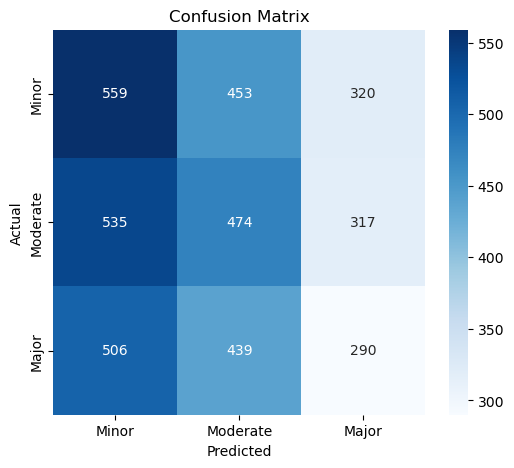

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Step 2: Class labels
class_names = ["Minor", "Moderate", "Major"]

# Step 3: Plot
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models

from sklearn.metrics import classification_report, confusion_matrix

In [10]:
base_model = EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model_eff = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dense(3, activation='softmax')
])

In [11]:
#compile 
model_eff.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [12]:
#train model 
history_eff = model_eff.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
572/572 ━━━━━━━━━━━━━━━━━━━━ 1129s 2s/step - accuracy: 0.3425 - loss: 1.1060 - val_accuracy: 0.3439 - val_loss: 1.0984
Epoch 2/5
572/572 ━━━━━━━━━━━━━━━━━━━━ 1454s 3s/step - accuracy: 0.3573 - loss: 1.0974 - val_accuracy: 0.3439 - val_loss: 1.0987
Epoch 3/5
572/572 ━━━━━━━━━━━━━━━━━━━━ 1093s 2s/step - accuracy: 0.3573 - loss: 1.0974 - val_accuracy: 0.3439 - val_loss: 1.0987
Epoch 4/5
572/572 ━━━━━━━━━━━━━━━━━━━━ 793s 1s/step - accuracy: 0.3573 - loss: 1.0973 - val_accuracy: 0.3439 - val_loss: 1.0987
Epoch 5/5
572/572 ━━━━━━━━━━━━━━━━━━━━ 771s 1s/step - accuracy: 0.3573 - loss: 1.0974 - val_accuracy: 0.3439 - val_loss: 1.0988


In [13]:
#evaluate accuracy 
test_loss, test_acc = model_eff.evaluate(test_data)

print("EfficientNet Test Accuracy:", test_acc)

122/122 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.3422 - loss: 1.0987
EfficientNet Test Accuracy: 0.34215259552001953


In [14]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred_eff = model_eff.predict(test_data)
y_pred_classes_eff = y_pred_eff.argmax(axis=1)

y_true = test_data.classes

print(classification_report(y_true, y_pred_classes_eff))

122/122 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step
              precision    recall  f1-score   support

           0       0.34      1.00      0.51      1332
           1       0.00      0.00      0.00      1326
           2       0.00      0.00      0.00      1235

    accuracy                           0.34      3893
   macro avg       0.11      0.33      0.17      3893
weighted avg       0.12      0.34      0.17      3893



C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


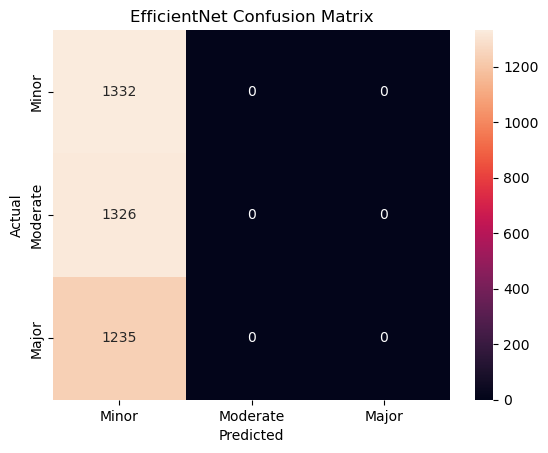

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

cm_eff = confusion_matrix(y_true, y_pred_classes_eff)

sns.heatmap(cm_eff, annot=True, fmt='d',
            xticklabels=["Minor","Moderate","Major"],
            yticklabels=["Minor","Moderate","Major"])

plt.title("EfficientNet Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [ ]:
base_path = "C:/Users/Dell/Documents/AIDSLAB_3rdsem/AIDSLAB_4thsem/Balanced Accident Video Dataset/frames"

train_dir = base_path + "/train"
val_dir = base_path + "/val"
test_dir = base_path + "/test"

datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_data = datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

test_data = datagen.flow_from_directory(
    test_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

class_names = ["Minor", "Moderate", "Major"]

In [3]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

base_path = "C:/Users/Dell/Documents/AIDSLAB_3rdsem/AIDSLAB_4thsem/Balanced Accident Video Dataset/frames"

train_dir = base_path + "/train"
val_dir = base_path + "/val"
test_dir = base_path + "/test"

datagen = ImageDataGenerator(rescale=1./255)

train_data = datagen.flow_from_directory(
    train_dir,
    target_size=(224,224),
    batch_size=8,   # 🔥 keep small
    class_mode='categorical'
)

val_data = datagen.flow_from_directory(
    val_dir,
    target_size=(224,224),
    batch_size=8,
    class_mode='categorical'
)

Found 18275 images belonging to 3 classes.
Found 4085 images belonging to 3 classes.


In [16]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

In [18]:
#build model 
base_model = VGG16(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

#  Freeze all layers (fast training)
base_model.trainable = False

In [19]:
model_vgg = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation='relu'),
    layers.Dense(3, activation='softmax')
])

In [20]:
#compile
model_vgg.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [21]:
#train
history_vgg = model_vgg.fit(
    train_data,
    validation_data=val_data,
    epochs=2,
    steps_per_epoch=30,
    validation_steps=10,
    verbose=1
)

Epoch 1/2
30/30 ━━━━━━━━━━━━━━━━━━━━ 380s 13s/step - accuracy: 0.3490 - loss: 1.1902 - val_accuracy: 0.3406 - val_loss: 1.1348
Epoch 2/2
30/30 ━━━━━━━━━━━━━━━━━━━━ 372s 13s/step - accuracy: 0.3385 - loss: 1.1153 - val_accuracy: 0.3812 - val_loss: 1.0837


In [22]:
test_loss, test_acc = model_vgg.evaluate(test_data)

print("VGG16 Test Accuracy:", test_acc)

122/122 ━━━━━━━━━━━━━━━━━━━━ 1159s 9s/step - accuracy: 0.3468 - loss: 1.0990 
VGG16 Test Accuracy: 0.3467762768268585


In [23]:
from sklearn.metrics import classification_report

y_pred_vgg = model_vgg.predict(test_data)
y_pred_classes_vgg = y_pred_vgg.argmax(axis=1)

y_true = test_data.classes

print(classification_report(y_true, y_pred_classes_vgg))

122/122 ━━━━━━━━━━━━━━━━━━━━ 1820s 15s/step
              precision    recall  f1-score   support

           0       0.34      1.00      0.51      1332
           1       0.93      0.01      0.02      1326
           2       0.44      0.01      0.01      1235

    accuracy                           0.35      3893
   macro avg       0.57      0.34      0.18      3893
weighted avg       0.57      0.35      0.19      3893



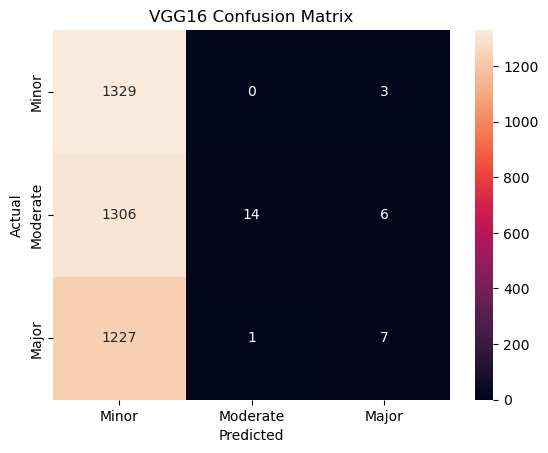

In [24]:
#confusion matrix 
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_vgg = confusion_matrix(y_true, y_pred_classes_vgg)

sns.heatmap(cm_vgg, annot=True, fmt='d',
            xticklabels=["Minor","Moderate","Major"],
            yticklabels=["Minor","Moderate","Major"])

plt.title("VGG16 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()